In [1]:
import json

with open("KRpolitician_youtube_comments_cleaned.json", "r", encoding="utf-8") as f:
    data = json.load(f)

In [2]:
import pandas as pd

In [3]:
rows = []

# Iterate through videos
for video in data:
    video_id = video.get("video_id")
    
    for comment in video.get("comments", []):
        # Top-level comment
        rows.append({
            "video_id": video_id,
            "comment_id": comment.get("comment_id"),
            "parent_id": None,
            "type": comment.get("type"),
            "text": comment.get("text"),
            "author": comment.get("author"),
            "like_count": comment.get("like_count"),
            "published_at": comment.get("published_at")
        })
        
        # Replies
        for reply in comment.get("replies", []):
            rows.append({
                "video_id": video_id,
                "comment_id": reply.get("comment_id"),
                "parent_id": comment.get("comment_id"),
                "type": "reply",
                "text": reply.get("text"),
                "author": reply.get("author"),
                "like_count": reply.get("like_count"),
                "published_at": reply.get("published_at")
            })

# Convert to DataFrame
df = pd.DataFrame(rows)

# Check
df

,video_id,comment_id,parent_id,type,text,author,like_count,published_at
0,-JUver7HReA,Ugy46xWt1XTJ7PoIDb94AaABAg,None,top_level,배준영 의원님 제2공철 꼭 해주세요,@kikikiililil,2,2026-03-08T00:17:30Z
1,-JUver7HReA,UgxCCMsehi2W0b4DPpp4AaABAg,None,top_level,국민의힘 국회의원 중에 일을 잘 하시는것 같습니다. 진심으로 응원합니다.,@DSPark-rb5me,2,2026-03-06T12:18:40Z
2,-JUver7HReA,UgzSbb7b5qo2Ssqf-814AaABAg,None,top_level,"가뜩이나 캐리어며 가방이며 무거운데, 환승 좀 안하고 편리하게 이용하고 싶어요",@malreview1,3,2026-03-03T04:52:22Z
3,qT1jv3WMpmo,UgxqkNAIZud2NCqb3_F4AaABAg,None,top_level,9호선 직결이 된다.안된다 말이많은데 도대체 어떠케 되는건가요?,@김정환-l1i,0,2026-02-23T14:30:12Z
4,msniYZifNRQ,UgzDZHsWMV4SL5ihtaB4AaABAg,None,top_level,박정훈 의원님 최고❤❤❤,@이명자-f3w,0,2026-02-23T20:52:56Z
...,...,...,...,...,...,...,...,...
362834,_7COUduNAOI,UgwgcBm6QuT7HCaxQmt4AaABAg,None,top_level,당이 아니라<br>사람 보고 뽑을꺼다. <br>집도 못사 결혼은 뭐하러해 라는 젋은...,@수요공급,0,2026-03-14T03:09:49Z
362835,_7COUduNAOI,UgwG4W9Fpr-a2_tXybl4AaABAg,None,top_level,살아보려고 발악을 하네 성준이,@Sosleepyyy-a,0,2026-03-13T13:57:17Z
362836,_7COUduNAOI,Ugwe5tPkAMRpFIc-DEN4AaABAg,None,top_level,미쳣군,@ksec하늘구름,1,2026-03-12T07:32:56Z
362837,_7COUduNAOI,UgwtzB8UWJt8kNeyKYZ4AaABAg,None,top_level,금투세 시행 안하실꺼라 믿어도 될까요?,@처리-p3b,2,2026-03-12T07:31:49Z


In [4]:
len(df)

362839

In [5]:
df = df.drop_duplicates()

In [6]:
len(df)

362045

In [7]:
with open("KR_politician_youtube_vids.json", "r", encoding="utf-8") as f:
    video_data = json.load(f)

video_df = pd.DataFrame(video_data)
merge_df = video_df[["id", "channelName", "channelUrl", "title", "url"]]

In [8]:
comments_merged = df.merge(
    merge_df,
    left_on="video_id",
    right_on="id",
    how="left"
)

In [9]:
comments_merged = comments_merged[["video_id", "comment_id", "parent_id", "type", "text", "author", "like_count", "channelName", "channelUrl"]]

In [11]:
channels = comments_merged["channelName"].dropna().unique().tolist()

for c in channels:
    print(c)

배준영TV
송파갑 박정훈
박정현
박주민TV
이과맨 박충권
박찬대
박홍근TV
박지혜tv
박정하TV
백종헌Tv
박홍배TV
박희승TV
파주시을 국회의원 박정
박해철TV
백전백승아(백승아TV)
박은정TV
박용갑TV
백선희
박수현TV
부승찬TV
복기왕TV
나경원TV
백혜련TV
서미화TV
서명옥 강남갑 국회의원
맹성규TV
문정복TV
노종면TV
문금주TV
문대림TV
남인순티브이
모두 모경종
박범계TV
문진석TV
박균택TV
박민규TV
민형배TV
민병덕TV
민홍철TV
박대출 (박대출의 진주 이야기)
박덕흠 [국회의원 더큼이]
박상혁TV
박상웅 선거캠프
국회의원 박성훈
김도읍
김동아TV
국회의원 박성민
박수민
박선원TV
박성준TV
김대식TV
순천 암행어사 김문수
박수영의 우아한TV
김상욱TV
김미애TV #미애이야기
주블리 김병주
김상훈TV
김민전TV
김민석TV
김석기TV
김선민TV
김성회의 옳은소리
김병기TV
김성환TV
김성원TV
김소희 TV
김선교TV
김승수 대구북구을 국회의원
날아라 예지! 달려라 태백!
김영배
일산은 김영환tv
김승원TV
김영호 의원
강민국TV
고민정 TV
융합캔버스 강승규TV
강경숙TV
김영진TV
곽규택TV
강명구TV
강득구TV
강선우
강대식tv
강준현TV
고동진 TV
곽상언TV
권영세 TV
권칠승TV
길건짧건 김건
김기웅TV
권성동 채널
김남희TV
구자근TV
김기현
떴다 떴다 권영진
김남근TV
권향엽TV
김교흥TV
부천 김기표 TV
김용만 의원
서삼석TV
김용민의원, 민트TV
김용태TV
서영교TV
서영석TV
김윤의 윤이버스
서일준TV
김윤덕TV
New 김우영TV
서왕진TV
김원이
국민의힘 국회의원 서지영
국회의원 서천호
김재섭
성일종TV
김장겸TV
김은혜TV
국회의원 김재원
손명수티비
소병훈TV
김정재
송기헌TV
손솔
송언석TV
현장소속 김종민
송석준TV
김정호TV
송옥주TV
김준혁의 빛나는 실용정치(공식)
한큐에 김한규
김준형TV
김태선 TV
김주영TV
신동욱의 시선
신정훈TV
김태년TV
신성범TV
신장식TV
송재봉 TV
안규백 TV
안도걸TV
김현t

In [10]:
pol_df = pd.read_excel(r"C:\Users\chldn\OneDrive\바탕 화면\22대국회의원SNS.xlsx")

# Create ideology label
# independent is center 
pol_df["ideology"] = pol_df["정당"].map({
    "더불어민주당": "left",
    "조국혁신당" : "left",
    "무소속" : "independent",
    "기본소득당" : "left",
    "진보당" : "left",
    "사회민주당" : "left",
    "개혁신당" : "right",
    "국민의 힘": "right",
    "국민의힘": "right"
})

In [13]:
pol_df.head()

,번호,대수,의원명,정당,소속위원회,지역,성별,당선횟수,당선방법,YouTube Channel,Instagram,youtubeName,instaName,ideology
0,1,제22대,강경숙,조국혁신당,교육위원회,비례대표,여,초선,비례대표,https://www.youtube.com/@%EA%B0%95%EA%B2%BD%EC...,https://www.instagram.com/grace.kang.165/,강경숙TV,강경숙,left
1,2,제22대,강대식,국민의힘,국방위원회,대구 동구군위군을,남,재선,지역구,https://www.youtube.com/@tv-li4jl,https://www.instagram.com/kangds88/,강대식tv,강대식 국민의힘 최고위원 / 동구을 국회의원,right
2,3,제22대,강득구,더불어민주당,"기후위기 특별위원회, 기후에너지환경노동위원회",경기 안양시만안구,남,재선,지역구,https://www.youtube.com/@kang_deukgu,https://www.instagram.com/deukgu_kang/,강득구TV,강득구,left
3,4,제22대,강명구,국민의힘,정무위원회,경북 구미시을,남,초선,지역구,https://www.youtube.com/@0909kmg,https://www.instagram.com/myounggu_kang/,강명구TV,강명구,right
4,5,제22대,강민국,국민의힘,정무위원회,경남 진주시을,남,재선,지역구,https://www.youtube.com/@strongwind01,https://www.instagram.com/minkukkang/,강민국TV,강민국,right


In [11]:
pol_df.rename(columns={"youtubeName": "channelName"}, inplace=True)

In [12]:
pol_df = pol_df.rename(columns={"Unnamed: 11": "channelName"})

In [13]:
merged = comments_merged.merge(
    pol_df[["channelName", "ideology"]],
    on="channelName",
    how="left"
)

In [14]:
merged.head()

,video_id,comment_id,parent_id,type,text,author,like_count,channelName,channelUrl,ideology
0,-JUver7HReA,Ugy46xWt1XTJ7PoIDb94AaABAg,None,top_level,배준영 의원님 제2공철 꼭 해주세요,@kikikiililil,2,배준영TV,https://www.youtube.com/channel/UCxKQm25dzAAA_...,right
1,-JUver7HReA,UgxCCMsehi2W0b4DPpp4AaABAg,None,top_level,국민의힘 국회의원 중에 일을 잘 하시는것 같습니다. 진심으로 응원합니다.,@DSPark-rb5me,2,배준영TV,https://www.youtube.com/channel/UCxKQm25dzAAA_...,right
2,-JUver7HReA,UgzSbb7b5qo2Ssqf-814AaABAg,None,top_level,"가뜩이나 캐리어며 가방이며 무거운데, 환승 좀 안하고 편리하게 이용하고 싶어요",@malreview1,3,배준영TV,https://www.youtube.com/channel/UCxKQm25dzAAA_...,right
3,qT1jv3WMpmo,UgxqkNAIZud2NCqb3_F4AaABAg,None,top_level,9호선 직결이 된다.안된다 말이많은데 도대체 어떠케 되는건가요?,@김정환-l1i,0,배준영TV,https://www.youtube.com/channel/UCxKQm25dzAAA_...,right
4,msniYZifNRQ,UgzDZHsWMV4SL5ihtaB4AaABAg,None,top_level,박정훈 의원님 최고❤❤❤,@이명자-f3w,0,송파갑 박정훈,https://www.youtube.com/channel/UCcnTo9FIpadCy...,right


In [15]:
counts = (
    merged.groupby(["author"])["comment_id"]
    .count()
    .reset_index(name="n_comments")
)

In [16]:
active_users = counts[counts["n_comments"] >= 20]["author"].unique()

In [17]:
filtered_df = merged[merged["author"].isin(active_users)]

In [18]:
filtered_df

,video_id,comment_id,parent_id,type,text,author,like_count,channelName,channelUrl,ideology
6,msniYZifNRQ,UgyiMCrCGIr7lAb2YpJ4AaABAg,None,top_level,이런 애들이 에피쿠로슨가뭔가하는 거런건가? 국회의원 한번만 할 수 있게 해야됨. 이...,@장호현-j2r,0,송파갑 박정훈,https://www.youtube.com/channel/UCcnTo9FIpadCy...,right
12,msniYZifNRQ,UgyrgEW5Q5hU_9UftDJ4AaABAg,None,top_level,당원과 지지자들이 명령한다 탈당해라 우리가 뽑은 우리 당대표 버릇없이 자꾸 사퇴...,@smui-u3k,0,송파갑 박정훈,https://www.youtube.com/channel/UCcnTo9FIpadCy...,right
14,msniYZifNRQ,UgyBR_oOyM37J2Syt2h4AaABAg,None,top_level,이사람 배현진이 윤리위 징계받으니 눈 뒤집어지셨네 맨날 사퇴야 집에는 들어가냐? ...,@smui-u3k,0,송파갑 박정훈,https://www.youtube.com/channel/UCcnTo9FIpadCy...,right
16,msniYZifNRQ,UgzmrJejeUL9AWMXwYB4AaABAg,None,top_level,박정훈 의원님 응원합니다 화이팅 🎉🎉🎉,@강정숙-m3y,2,송파갑 박정훈,https://www.youtube.com/channel/UCcnTo9FIpadCy...,right
41,msniYZifNRQ,UgyFQbh4UT57yIkYyUJ4AaABAg,None,top_level,열심히 일하는 박정훈의원님 응원합니다 든든합니다,@보수어게인taer184,6,송파갑 박정훈,https://www.youtube.com/channel/UCcnTo9FIpadCy...,right
...,...,...,...,...,...,...,...,...,...,...
362839,uz-QNr5xkdw,UgxBS0At7Cy_wFNX3SB4AaABAg.ARdCLarbSCNARkH14YzzDy,UgxBS0At7Cy_wFNX3SB4AaABAg,reply,​@yuha47 2찍 뉴스 2찍 채널에 들어가니까 그렇지!!!!,@김태현-taehyeon,1,진성준 TV,https://www.youtube.com/channel/UCzWEju7x5X_6-...,left
362842,uz-QNr5xkdw,UgxBS0At7Cy_wFNX3SB4AaABAg.ARdCLarbSCNARkK1zQSQqJ,UgxBS0At7Cy_wFNX3SB4AaABAg,reply,​@yuha47 그 범인은 내란당 장건국2 밑에 있는 것들이겠지?!!!!!!!!!!...,@김태현-taehyeon,1,진성준 TV,https://www.youtube.com/channel/UCzWEju7x5X_6-...,left
362845,r2Wt7ucJbDI,UgzVD5lhTmqM8RssSip4AaABAg,None,top_level,저도 부끄러워 죽을 것 같아요 진선미의원님ㅜㅜ,@김태현-taehyeon,0,진선미TV,https://www.youtube.com/channel/UCJjg88xb_nV02...,left
362847,oxep2YoZdCI,UgyMbL2C2r383irs-Oh4AaABAg,None,top_level,맞습니다<br>어른들께서 가장 큰 문제입니다 진선미의원님,@김태현-taehyeon,1,진선미TV,https://www.youtube.com/channel/UCJjg88xb_nV02...,left


In [19]:
user_counts = (
    filtered_df
    .groupby(['author', 'ideology'])
    .size()
    .unstack(fill_value=0)
)

for col in ["left", "right"]:
    if col not in user_counts.columns:
        user_counts[col] = 0

user_counts["user_bias"] = (
    (user_counts["right"] - user_counts["left"]) /
    (user_counts["right"] + user_counts["left"])
)

In [20]:
filtered_df["ideology"].value_counts()

ideology
left           26375
right          18808
independent     2515
Name: count, dtype: int64

In [21]:
user_counts = user_counts.reset_index()

user_counts["platform"] = "YouTube"
user_counts["producer_type"] = "Politician"

In [22]:
user_counts.to_csv("D:/School/2026 Spring/independent_study/datasets/politicians/youtube/user_counts.csv", index=False)

In [23]:
user_counts

ideology,author,independent,left,right,user_bias,platform,producer_type
0,@0109jean,5,14,5,-0.473684,YouTube,Politician
1,@0603V,1,44,0,-1.000000,YouTube,Politician
2,@0909kmg,0,0,42,1.000000,YouTube,Politician
3,@104BaekSa,0,32,0,-1.000000,YouTube,Politician
4,@1q1q1q1q-p3j,0,0,31,1.000000,YouTube,Politician
...,...,...,...,...,...,...,...
1263,@흠흠-c9h,1,0,47,1.000000,YouTube,Politician
1264,@흥금동이,6,15,0,-1.000000,YouTube,Politician
1265,@희-p9u,0,0,45,1.000000,YouTube,Politician
1266,@희망-v5g,1,52,0,-1.000000,YouTube,Politician


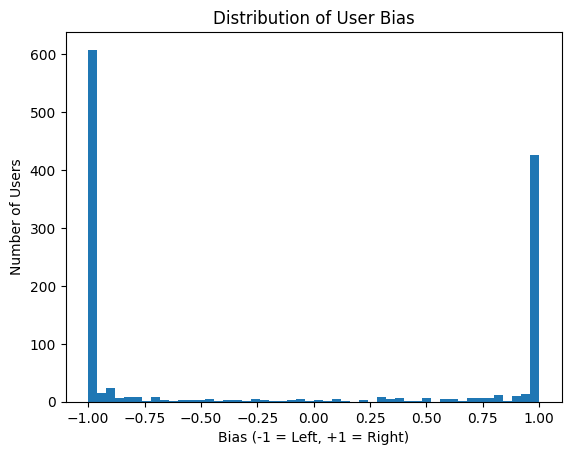

In [24]:
import matplotlib.pyplot as plt

plt.hist(user_counts["user_bias"], bins=50)
plt.title("Distribution of User Bias")
plt.xlabel("Bias (-1 = Left, +1 = Right)")
plt.ylabel("Number of Users")
plt.show()


In [25]:
import numpy as np
# total interactions (only left + right)
user_counts = user_counts.copy()
user_counts["total"] = user_counts["left"] + user_counts["right"]

# avoid division by zero
user_counts = user_counts[user_counts["total"] > 0]

# determine user side
user_counts["leaning"] = user_counts["user_bias"].apply(
    lambda x: "right" if x > 0 else ("left" if x < 0 else "center")
)

# compute cross-cutting exposure
def compute_cross_cutting(row):
    if row["leaning"] == "right":
        return row["left"] / row["total"]
    elif row["leaning"] == "left":
        return row["right"] / row["total"]
    else:
        return np.nan  # or 0, depending on your design

user_counts["cross_cutting"] = user_counts.apply(compute_cross_cutting, axis=1)

In [29]:
user_counts

ideology,author,independent,left,right,user_bias,platform,producer_type,total,leaning,cross_cutting
0,@0109jean,5,14,5,-0.473684,YouTube,Politician,19,left,0.263158
1,@0603V,1,44,0,-1.000000,YouTube,Politician,44,left,0.000000
2,@0909kmg,0,0,42,1.000000,YouTube,Politician,42,right,0.000000
3,@104BaekSa,0,32,0,-1.000000,YouTube,Politician,32,left,0.000000
4,@1q1q1q1q-p3j,0,0,31,1.000000,YouTube,Politician,31,right,0.000000
...,...,...,...,...,...,...,...,...,...,...
1263,@흠흠-c9h,1,0,47,1.000000,YouTube,Politician,47,right,0.000000
1264,@흥금동이,6,15,0,-1.000000,YouTube,Politician,15,left,0.000000
1265,@희-p9u,0,0,45,1.000000,YouTube,Politician,45,right,0.000000
1266,@희망-v5g,1,52,0,-1.000000,YouTube,Politician,52,left,0.000000


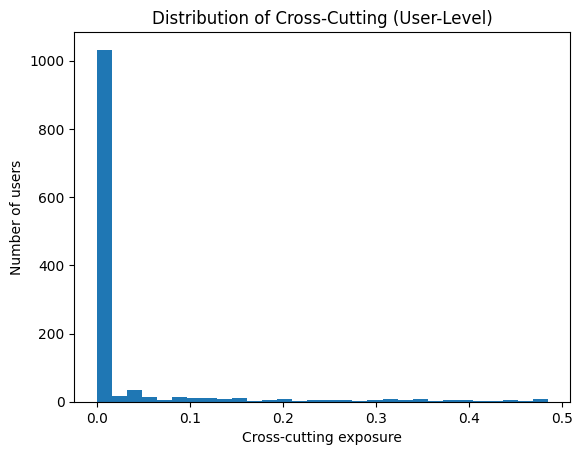

In [26]:
import matplotlib.pyplot as plt

plt.hist(user_counts["cross_cutting"].dropna(), bins=30)

plt.xlabel("Cross-cutting exposure")
plt.ylabel("Number of users")
plt.title("Distribution of Cross-Cutting (User-Level)")

plt.show()

In [27]:
bins = [20, 50, 100, 300, 1000, np.inf]
labels = ["20–49", "50–99", "100–299", "300–999", "1000+"]

user_counts["activity_band"] = pd.cut(
    user_counts["total"],
    bins=bins,
    labels=labels,
    right=False
)

In [28]:
band_summary = (
    user_counts
    .groupby("activity_band")[["user_bias", "cross_cutting"]]
    .mean()
    .reset_index()
)

C:\Users\chldn\AppData\Local\Temp\ipykernel_30156\2619608654.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("activity_band")[["user_bias", "cross_cutting"]]


In [29]:
import numpy as np

band_stats = (
    user_counts
    .groupby("activity_band")["cross_cutting"]
    .agg(["mean", "std", "count"])
    .reset_index()
)

# Standard Error
band_stats["se"] = (
    band_stats["std"] /
    np.sqrt(band_stats["count"])
)

# 95% Confidence Interval
band_stats["ci95"] = 1.96 * band_stats["se"]

print(band_stats)

  activity_band      mean       std  count        se      ci95
0         20–49  0.027912  0.082632    997  0.002617  0.005129
1         50–99  0.043242  0.115793    150  0.009454  0.018531
2       100–299  0.040035  0.108304     33  0.018853  0.036952
3       300–999  0.024336       NaN      1       NaN       NaN
4         1000+  0.028930       NaN      1       NaN       NaN


C:\Users\chldn\AppData\Local\Temp\ipykernel_30156\2513221513.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("activity_band")["cross_cutting"]


In [42]:
band_summary

ideology,activity_band,user_bias,cross_cutting
0,20–49,-0.113648,0.027912
1,50–99,-0.138877,0.043242
2,100–299,-0.318927,0.040035
3,300–999,0.951327,0.024336
4,1000+,-0.942141,0.028930


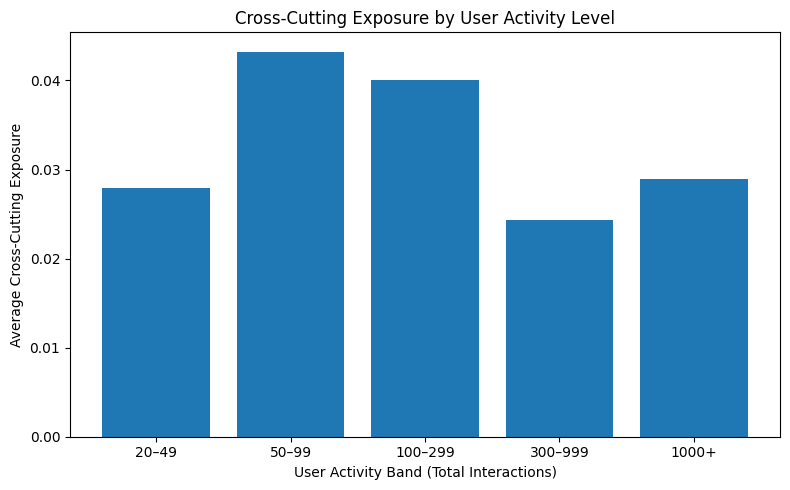

In [33]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.bar(band_summary["activity_band"].astype(str),
        band_summary["cross_cutting"])

plt.xlabel("User Activity Band (Total Interactions)")
plt.ylabel("Average Cross-Cutting Exposure")
plt.title("Cross-Cutting Exposure by User Activity Level")

plt.tight_layout()
plt.show()

In [38]:
band_summary = (
    user_counts
    .dropna(subset=["cross_cutting"])
    .groupby("activity_band", observed=True)
    .apply(
        lambda g: np.average(
            g["cross_cutting"],
            weights=g["total"]
        )
    )
    .reset_index(name="weighted_cross_cutting")
)

C:\Users\chldn\AppData\Local\Temp\ipykernel_8184\3072711999.py:5: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(


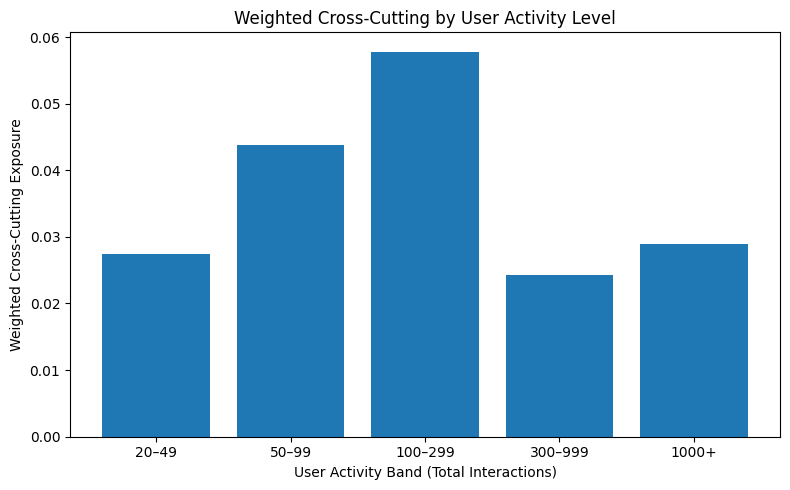

In [39]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.bar(
    band_summary["activity_band"].astype(str),
    band_summary["weighted_cross_cutting"]
)

plt.xlabel("User Activity Band (Total Interactions)")
plt.ylabel("Weighted Cross-Cutting Exposure")
plt.title("Weighted Cross-Cutting by User Activity Level")

plt.tight_layout()
plt.show()

In [ ]:
# unweighted
band_unweighted = (
    user_counts
    .dropna(subset=["cross_cutting"])
    .groupby("activity_band")["cross_cutting"]
    .mean()
    .reset_index(name="unweighted")
)

# merge
band_compare = band_unweighted.merge(
    band_summary,
    on="activity_band"
)

C:\Users\chldn\AppData\Local\Temp\ipykernel_6284\1167140726.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("activity_band")["cross_cutting"]


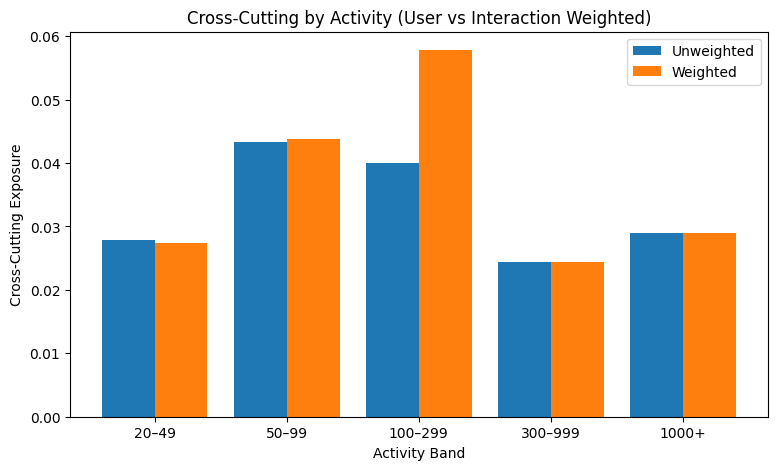

In [ ]:
x = range(len(band_compare))

plt.figure(figsize=(9,5))

plt.bar(x, band_compare["unweighted"], width=0.4, label="Unweighted")
plt.bar([i+0.4 for i in x], band_compare["weighted_cross_cutting"], width=0.4, label="Weighted")

plt.xticks([i+0.2 for i in x], band_compare["activity_band"].astype(str))
plt.xlabel("Activity Band")
plt.ylabel("Cross-Cutting Exposure")
plt.title("Cross-Cutting by Activity (User vs Interaction Weighted)")

plt.legend()
plt.show()